In [1]:
import os
# Kernel Restarts
!pip install --upgrade ipywidgets --quiet
!pip install --upgrade transformers --quiet
!pip install --upgrade pip --quiet
!pip install -q ftfy regex tqdm torch torchvision git+https://github.com/openai/CLIP.git

# !pip install -U transformers==4.54.1 --quiet
!pip uninstall -y tensorflow --quiet && !pip install tensorflow-cpu --quiet

print("Done installing! Restarting kernel...")
# os.kill(os.getpid(), 9)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 2.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
bigframes 2.12.0 requires google-cloud-bigquery[bqstorage,pandas]>=3.31.0, but you have google-cloud-bigquery 3.25.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.1.0 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 87.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.1/566.1 kB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 98.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are inst

In [2]:
import os
# os.kill(os.getpid(), 9)

# Imports

In [3]:
# multimodal_5fold_cv.py
import os
import random
import pickle
from pathlib import Path
from tqdm.notebook import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from PIL import Image
import warnings

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.cuda.amp import autocast, GradScaler

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    T5EncoderModel,
    get_scheduler,
)

import clip
import time


warnings.filterwarnings("ignore")

print("="*50)
print("All imports complete")

All imports complete


In [4]:
SENTIMENTS_TO_LABELS = {"negative": 0, "neutral": 1, "positive": 2}
LABELS_TO_SENTIMENTS = {0: "negative", 1: "neutral", 2: "positive"}

In [5]:
# ----------------------------
# User-editable paths & names
# ----------------------------
EPOCHS = 25
CSV_PATH = "/kaggle/input/musait/MUSAIT__all_info_uniques.csv"   # <<-- change to your CSV path
OUTPUT_DIR = f"./crossVal_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [6]:
# !rm -rf /kaggle/working/crossVal_results_allEvalMetrics_25

In [7]:
# help(pd.read_csv)

In [8]:
df = pd.read_csv(CSV_PATH, index_col=0)
df.head(2)

,filename,filepath,text-detected,OCR,coordinates,img_ar,img_or,img_area,txt_ar,txt_or,txt_area,txt_img_ratio,sentiment
0,negative_001.jpg,/kaggle/input/musait/basket_unique/negative_00...,1,STOP WAR\nUKRAINE\nIN\nСлава Україні!\nMAKE\nNOT,"[{'x': 513, 'y': 24}, {'x': 975, 'y': 24}, {'x...",16:9,horizontal,535824,16:9,horizontal,110418,0.206071,negative
1,negative_002.jpg,/kaggle/input/musait/basket_unique/negative_00...,1,HUNDREDS\nKILLED IN\nUKRAINE\n>NEWS\nNIGHTLY AT 6,"[{'x': 20, 'y': 61}, {'x': 508, 'y': 61}, {'x'...",16:9,horizontal,921600,3:4,vertical,313784,0.340477,negative


In [9]:
# df['filepath'] = df['filepath'].str.replace('dataset/basket', 'basket_unique')
# df.to_csv(CSV_PATH.split("/")[-1])

In [10]:
# CSV expected columns mapping (edit if different)
CSV_COLS = {
    "image": "filepath",   # column containing image file paths
    "text":  "OCR",         # column containing OCR/text
    "label": "sentiment",        # column containing labels (0,1,2) OR text labels
}


# ----------------------------
# Hyperparams (taken from T5 notebook)
# ----------------------------
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LEARNING_RATE = 2e-4
BATCH_SIZE = 16
EPOCHS = 25

MAX_LENGTH = 128
EMBED_DIM = 512

NUM_FOLDS = 5
NUM_CLASSES = 3

SAVE_MODELS = False


TEXT_MODEL_NAME = "t5-base"
IMAGE_MODEL_NAME = "ViT-B/32"

# reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

print("="*50)
print("Seed set")

Seed set


# User-defined functions

In [11]:
# ----------------------------
# Dataset
# ----------------------------
from PIL import Image

class MultimodalDataset(Dataset):
    def __init__(self, df, text_tokenizer, image_preprocess, max_length=128, cols=CSV_COLS):
        self.df = df.reset_index(drop=True)
        self.text_tokenizer = text_tokenizer
        self.image_preprocess = image_preprocess
        self.max_length = max_length
        self.cols = cols

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        # print(self.cols)
        # print(row[self.cols["label"]])
        img_path = row[self.cols["image"]]
        text = str(row[self.cols["text"]])
        # label = SENTIMENTS_TO_LABELS[row[self.cols["label"]]]
        label = row[self.cols["label"]]

        # load image
        image = Image.open(img_path).convert("RGB")

        # text encoding (T5 tokenizer)
        text_inputs = self.text_tokenizer(
            text,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        # CLIP image processing
        # image_inputs = self.image_preprocess(images=image, return_tensors="pt")
        image_inputs = self.image_preprocess(image)

        # squeeze tensors (remove batch dim)
        ti = {k: v.squeeze(0) for k, v in text_inputs.items()}
        # ii = {k: v.squeeze(0) for k, v in image_inputs.items()} # This works if image_inputs is a dict
        ii = {"pixel_values": image_inputs} # This works when itself is a tensor

        return {
            "input_ids": ti["input_ids"],
            "attention_mask": ti["attention_mask"],
            "pixel_values": ii["pixel_values"],
            "label": torch.tensor(int(label), dtype=torch.long),
        }

In [12]:
# ----------------------------
# Model wrappers (lightweight heads)
# ----------------------------

# ==================================================================================================
# ======================================== NOT USED ================================================
# ==================================================================================================

class T5TextClassifier(nn.Module):
    def __init__(self, model_name="t5-small", num_classes=3):
        super().__init__()
        # Use T5 encoder for classification (consistent with your T5 notebook)
        self.encoder = T5EncoderModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.d_model
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        # mean pool last_hidden_state (batch, seq_len, hidden)
        last = out.last_hidden_state  # (B, L, H)
        pooled = last.mean(dim=1)     # (B, H)
        logits = self.classifier(pooled)
        return logits

In [13]:
class CLIPClassifier(nn.Module):
    def __init__(self, encoder, embed_dim, num_classes):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, image):
        image = image.to(dtype=self.encoder.conv1.weight.dtype)  # usually float16
        with torch.no_grad():
            x = self.encoder(image)
        x = x.float()  # Convert back to float32 for classifier
        return self.classifier(x)

In [14]:
# ----------------------------
# Utility functions
# ----------------------------
def train_one_epoch(model, dataloader, optimizer, scheduler, criterion, device, scaler, mode):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    index = 1
    for batch in tqdm(dataloader, desc=f"{mode} Training over batches round-{index}"):
        optimizer.zero_grad()
        labels = batch["label"].to(device)
        with autocast():
            # if isinstance(model, T5TextClassifier):
            if not isinstance(model, CLIPClassifier): # text
                logits = model(
                    input_ids=batch["input_ids"].to(device),
                    attention_mask=batch["attention_mask"].to(device),
                    labels=labels
                )
            else:
                logits = model(batch["pixel_values"].to(device))

            # loss = criterion(logits, labels)
            if hasattr(logits, "logits"):
                logits = logits.logits
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        if scheduler is not None:
            scheduler.step()

        running_loss += loss.item() * labels.size(0)
        preds = torch.argmax(logits.detach().cpu(), dim=1).numpy()
        correct += (preds == labels.cpu().numpy()).sum()
        total += labels.size(0)
        index += 1

    avg_loss = running_loss / total
    acc = correct / total
    return avg_loss, acc

In [15]:
def validate(model, dataloader, criterion, device, mode):
    model.eval()
    running_loss = 0.0
    total = 0
    correct = 0
    all_probs = []
    all_labels = []

    index = 1
    with torch.no_grad():
        for batch in tqdm(dataloader, desc=f"{mode} Validating over batches: round-{index}"):
            labels = batch["label"].to(device)
            # if isinstance(model, T5TextClassifier):
            if not isinstance(model, CLIPClassifier): # text
                logits = model(
                    input_ids=batch["input_ids"].to(device),
                    attention_mask=batch["attention_mask"].to(device),
                )
            else:
                logits = model(batch["pixel_values"].to(device))

            # loss = criterion(logits, labels)
            # Hugging Face models return an object with .logits attribute
            if hasattr(logits, "logits"):
                logits = logits.logits
            loss = criterion(logits, labels)
            
            probs = torch.softmax(logits, dim=1).detach().cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels.detach().cpu().numpy())

            running_loss += loss.item() * labels.size(0)
            preds = logits.argmax(dim=1).detach().cpu().numpy()
            correct += (preds == labels.detach().cpu().numpy()).sum()
            total += labels.size(0)
            index += 1

    avg_loss = running_loss / total
    acc = correct / total
    all_probs = np.concatenate(all_probs, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    return avg_loss, acc, all_probs, all_labels

In [16]:
df.head(2)

,filename,filepath,text-detected,OCR,coordinates,img_ar,img_or,img_area,txt_ar,txt_or,txt_area,txt_img_ratio,sentiment
0,negative_001.jpg,/kaggle/input/musait/basket_unique/negative_00...,1,STOP WAR\nUKRAINE\nIN\nСлава Україні!\nMAKE\nNOT,"[{'x': 513, 'y': 24}, {'x': 975, 'y': 24}, {'x...",16:9,horizontal,535824,16:9,horizontal,110418,0.206071,negative
1,negative_002.jpg,/kaggle/input/musait/basket_unique/negative_00...,1,HUNDREDS\nKILLED IN\nUKRAINE\n>NEWS\nNIGHTLY AT 6,"[{'x': 20, 'y': 61}, {'x': 508, 'y': 61}, {'x'...",16:9,horizontal,921600,3:4,vertical,313784,0.340477,negative


In [17]:
SENTIMENTS_TO_LABELS

{'negative': 0, 'neutral': 1, 'positive': 2}

In [18]:
# ----------------------------
# Read CSV and prepare labels
# ----------------------------
df = pd.read_csv(CSV_PATH)

# Normalize column names if required; ensure label column numeric
label_col = CSV_COLS["label"]
if df[label_col].dtype == object and SENTIMENTS_TO_LABELS is not None:
    df[label_col] = df[label_col].map(SENTIMENTS_TO_LABELS)
    if df[label_col].isnull().any():
        raise ValueError("Some labels could not be mapped. Check TEXT_LABEL_TO_INT mapping.")

# Model initializations

In [19]:
# device = "cuda" if torch.cuda.is_available() else "cpu"

In [20]:
# -------------------------------- T5 Model ------------------------------------------

# loading the tokenizer and model from HF transformers
text_tokenizer = AutoTokenizer.from_pretrained(TEXT_MODEL_NAME)

# num_labels = 3 for Postive, Neutral, and Negative sentiment classes
text_model = AutoModelForSequenceClassification.from_pretrained(TEXT_MODEL_NAME, num_labels=NUM_CLASSES).to(DEVICE)

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

Some weights of T5ForSequenceClassification were not initialized from the model checkpoint at t5-base and are newly initialized: ['classification_head.dense.bias', 'classification_head.dense.weight', 'classification_head.out_proj.bias', 'classification_head.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [21]:
clip_model, image_preprocess = clip.load("ViT-B/32", device=DEVICE)
image_encoder = clip_model.visual

image_model = CLIPClassifier(image_encoder, embed_dim=EMBED_DIM, num_classes=NUM_CLASSES).to(DEVICE)

100%|████████████████████████████████████████| 338M/338M [00:00<00:00, 373MiB/s]


In [22]:
isinstance(image_model, CLIPClassifier)

True

In [23]:
# ----------------------------
# Cross-validation setup
# ----------------------------
skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=SEED)
X = df[[CSV_COLS["image"], CSV_COLS["text"]]]
y = df[CSV_COLS["label"]].values

fold_results = []
precision_results = []
recall_results = []
f1_results = []

all_fold_histories = {}

In [24]:
X.head(2)

,filepath,OCR
0,/kaggle/input/musait/basket_unique/negative_00...,STOP WAR\nUKRAINE\nIN\nСлава Україні!\nMAKE\nNOT
1,/kaggle/input/musait/basket_unique/negative_00...,HUNDREDS\nKILLED IN\nUKRAINE\n>NEWS\nNIGHTLY AT 6


In [25]:
y

array([0, 0, 0, ..., 2, 2, 2])

In [26]:
assert len(y)==len(X)

In [27]:
# EPOCHS = 1
EPOCHS

25

In [28]:
import multiprocessing
print(multiprocessing.cpu_count())

4


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

test_idx = np.array(X_test.index.tolist())

In [30]:
warnings.filterwarnings("ignore")

skf_splits = enumerate(skf.split(X_train, y_train), start=1)

In [31]:
for fold, (train_idx, val_idx) in tqdm(skf_splits, desc="SKF Split folds"):
    print("\n", "="*35, f" Fold {fold}/{NUM_FOLDS}", "="*35)
    print(train_idx)
    # print(test_idx)
    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df  = df.iloc[val_idx].reset_index(drop=True)
    test_df  = df.iloc[test_idx].reset_index(drop=True)

    # Optionally create a small validation split out of train_df
    # val_frac = 0.1
    # val_count = max(1, int(len(train_df) * val_frac))
    # val_df = train_df.sample(n=val_count, random_state=SEED)
    # train_df = train_df.drop(val_df.index).reset_index(drop=True)
    # val_df = val_df.reset_index(drop=True)

    # Datasets & loaders
    train_dataset = MultimodalDataset(train_df, text_tokenizer, 
                                      image_preprocess, 
                                      max_length=MAX_LENGTH)
    
    val_dataset   = MultimodalDataset(val_df, text_tokenizer, 
                                      image_preprocess, 
                                      max_length=MAX_LENGTH)
    
    test_dataset  = MultimodalDataset(test_df, text_tokenizer, 
                                      image_preprocess, 
                                      max_length=MAX_LENGTH)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
    val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
    test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
    
    # print(train_loader)
    # batch = next(iter(train_loader))
    # Now inspect what's inside
    # for k, v in batch.items():
    #     print(f"{k}: shape = {v.shape}, dtype = {v.dtype}")

    # Instantiate models for this fold
    # text_model = T5TextClassifier(model_name=t5_name, num_classes=NUM_CLASSES).to(DEVICE)
    # image_model = CLIPImageClassifier(num_classes=NUM_CLASSES).to(DEVICE)

    # optimizer grouping & AdamW
    def setup_optimizer(model, lr):
        no_decay = ["bias", "LayerNorm.weight"]
        optimizer_grouped_parameters = [
            {
                "params": [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
                "weight_decay": 0.01,
            },
            {
                "params": [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
                "weight_decay": 0.0,
            },
        ]
        return AdamW(optimizer_grouped_parameters, lr=lr)

    opt_text = setup_optimizer(text_model, LEARNING_RATE)
    opt_image = setup_optimizer(image_model, LEARNING_RATE)

    # Schedulers: linear decay as in reference
    # compute num_training_steps for each model: epochs * (len(train_loader))
    num_training_steps_text = EPOCHS * len(train_loader)
    num_training_steps_image = EPOCHS * len(train_loader)

    scheduler_text = get_scheduler(
        name="linear",
        optimizer=opt_text,
        num_warmup_steps=0,
        num_training_steps=num_training_steps_text,
    )
    scheduler_image = get_scheduler(
        name="linear",
        optimizer=opt_image,
        num_warmup_steps=0,
        num_training_steps=num_training_steps_image,
    )

    criterion = nn.CrossEntropyLoss()

    # scaler for AMP
    scaler_text = GradScaler()
    scaler_image = GradScaler()

    # For history logging
    history = {
        "text": {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []},
        "image": {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []},
        "fused_test_acc": None,
        "fused_test_precision_macro": None,
        "fused_test_recall_macro": None,
        "fused_test_f1_macro": None
    }

    # ----------------------------
    # Training loops for this fold
    # ----------------------------
    time_epoch = []
    for epoch in tqdm(range(EPOCHS), desc = "Training over epochs"):
        # text train epoch
        start = time.time()
        t_loss, t_acc = train_one_epoch(text_model, train_loader, opt_text, scheduler_text, criterion, DEVICE, scaler_text, mode="TEXT")
        end = time.time()
        vt_loss, vt_acc, _, _ = validate(text_model, val_loader, criterion, DEVICE, mode="TEXT")
        diff = end - start
        # image train epoch
        start = time.time()
        i_loss, i_acc = train_one_epoch(image_model, train_loader, opt_image, scheduler_image, criterion, DEVICE, scaler_image, mode="IMAGE")
        end = time.time()
        vi_loss, vi_acc, _, _ = validate(image_model, val_loader, criterion, DEVICE, mode="IMAGE")
        diff += end - start
        diff /= 2
        time_epoch += [diff]

        history["text"]["train_loss"].append(t_loss)
        history["text"]["train_acc"].append(t_acc)
        history["text"]["val_loss"].append(vt_loss)
        history["text"]["val_acc"].append(vt_acc)

        history["image"]["train_loss"].append(i_loss)
        history["image"]["train_acc"].append(i_acc)
        history["image"]["val_loss"].append(vi_loss)
        history["image"]["val_acc"].append(vi_acc)

        # print("-"*50)
        print(f"Fold {fold}: Epoch {epoch+1}/{EPOCHS}")
        print(f"T:\ttrain_loss={t_loss:.4f}\ttrain_acc={t_acc:.4f}\tval_loss={vt_loss:.4f}\tval_acc={vt_acc:.4f}")
        print(f"I:\ttrain_loss={i_loss:.4f}\ttrain_acc={i_acc:.4f}\tval_loss={vi_loss:.4f}\tval_acc={vi_acc:.4f}")
        print(f"--------- Average time taken: {diff:.4f}")

    # ----------------------------
    # Evaluate on test set and do probability fusion
    # ----------------------------
    # Get text probs
    _, _, text_probs_test, text_labels_test = validate(text_model, test_loader, criterion, DEVICE, mode="TEXT")
    _, _, image_probs_test, image_labels_test = validate(image_model, test_loader, criterion, DEVICE, mode="IMAGE")
    
    # Sanity: labels must match
    assert (text_labels_test == image_labels_test).all()
    # image_labels_test = TRUE LABELs of the test_loader instances
    # text_labels_test = TRUE LABELs of the test_loader instances

    fused_probs = 0.5 * text_probs_test + 0.5 * image_probs_test
    fused_preds = np.argmax(fused_probs, axis=1)
    fused_acc = accuracy_score(text_labels_test, fused_preds)

    # Compute macro metrics
    precision_macro = precision_score(text_labels_test, fused_preds, average='macro')
    recall_macro = recall_score(text_labels_test, fused_preds, average='macro')
    f1_macro = f1_score(text_labels_test, fused_preds, average='macro')

    print(f"Fold {fold} fused test accuracy: {fused_acc:.4f}")
    print(f"Fold {fold} fused test macro-precision: {precision_macro:.4f}")
    print(f"Fold {fold} fused test macro-recall: {recall_macro:.4f}")
    print(f"Fold {fold} fused test macro-f1: {f1_macro:.4f}")
    print(f"Fold {fold} average time taken: {(sum(time_epoch)):.4f}s")

    history["fused_test_acc"] = float(fused_acc)
    history["fused_test_precision_macro"] = float(precision_macro)
    history["fused_test_recall_macro"] = float(recall_macro)
    history["fused_test_f1_macro"] = float(f1_macro)
    
    fold_results.append(fused_acc)
    precision_results.append(precision_macro)
    recall_results.append(recall_macro)
    f1_results.append(f1_macro)
    all_fold_histories[f"fold_{fold}"] = history

    # save history pickle
    hist_path = os.path.join(OUTPUT_DIR, f"history_fold_{fold}.json")
    # with open(hist_path, "wb") as f:
    #     pickle.dump(history, f)
    with open(hist_path, "w") as f:
        json.dump(history, f, indent=4)

    # save models (optional)
    if SAVE_MODELS:
        torch.save(text_model.state_dict(), os.path.join(OUTPUT_DIR, f"text_model_fold_{fold}.pt"))
        torch.save(image_model.state_dict(), os.path.join(OUTPUT_DIR, f"image_model_fold_{fold}.pt"))

    # -----------------------------
    # Plot learning curves and save
    # -----------------------------
    def plot_and_save(history_part, title, save_path):
        epochs_range = range(1, len(history_part["train_loss"]) + 1)
        plt.figure(figsize=(10,4))
        plt.subplot(1,2,1)
        plt.plot(epochs_range, history_part["train_loss"], label="train_loss")
        plt.plot(epochs_range, history_part["val_loss"], label="val_loss")
        plt.title(title + " - Loss")
        plt.xlabel("Epoch")
        plt.legend()
        plt.subplot(1,2,2)
        plt.plot(epochs_range, history_part["train_acc"], label="train_acc")
        plt.plot(epochs_range, history_part["val_acc"], label="val_acc")
        plt.title(title + " - Accuracy")
        plt.xlabel("Epoch")
        plt.legend()
        plt.tight_layout()
        plt.savefig(save_path)
        plt.close()

    plot_and_save(history["text"], f"Fold{fold}_T5", os.path.join(OUTPUT_DIR, f"learning_curve_fold_{fold}_t5.png"))
    plot_and_save(history["image"], f"Fold{fold}_CLIP", os.path.join(OUTPUT_DIR, f"learning_curve_fold_{fold}_clip.png"))
    # break

SKF Split folds: 0it [00:00, ?it/s]


 ===================================  Fold 1/5 ===================================
[   0    2    3 ... 1638 1639 1640]


Training over epochs:   0%|          | 0/25 [00:00<?, ?it/s]

TEXT Training over batches round-1:   0%|          | 0/83 [00:00<?, ?it/s]

TEXT Validating over batches: round-1:   0%|          | 0/21 [00:00<?, ?it/s]

...

IMAGE Validating over batches: round-1:   0%|          | 0/21 [00:00<?, ?it/s]

Fold 5: Epoch 25/25
T:	train_loss=0.0731	train_acc=0.9605	val_loss=0.0727	val_acc=0.9604
I:	train_loss=0.1163	train_acc=0.9703	val_loss=0.1199	val_acc=0.9634
--------- Average time taken: 20.1144


TEXT Validating over batches: round-1:   0%|          | 0/26 [00:00<?, ?it/s]

IMAGE Validating over batches: round-1:   0%|          | 0/26 [00:00<?, ?it/s]

Fold 5 fused test accuracy: 0.9708
Fold 5 fused test macro-precision: 0.9708
Fold 5 fused test macro-recall: 0.9725
Fold 5 fused test macro-f1: 0.9713
Fold 5 average time taken: 503.5406s


In [32]:
len(fold_results)

5

In [33]:
# ----------------------------
# Summary across folds
# ----------------------------
fold_results = np.array(fold_results)
mean_acc = float(fold_results.mean())
std_acc = float(fold_results.std(ddof=1))

precision_results = np.array(precision_results)
mean_pr = float(precision_results.mean())
std_pr = float(precision_results.std(ddof=1))

recall_results = np.array(recall_results)
mean_rec = float(recall_results.mean())
std_rec = float(recall_results.std(ddof=1))

f1_results = np.array(f1_results)
mean_f1 = float(f1_results.mean())
std_f1 = float(f1_results.std(ddof=1))


print(f"\n=== Cross-validation summary over {NUM_FOLDS} folds ===")
for i, acc in enumerate(fold_results):
    print(f"Fold {i+1}: fused_test_acc = {acc:.4f}")
    print(f"Fold {i+1}: macro precision = {precision_results[i]:.4f}")
    print(f"Fold {i+1}: macro recall = {recall_results[i]:.4f}")
    print(f"Fold {i+1}: macro F1 = {f1_results[i]:.4f}")
    print("-"*50)
    
print(f"Mean fused accuracy = {mean_acc:.4f}")
print(f"Std dev fused accuracy = {std_acc:.4f}")
print()

print(f"Mean macro precision = {mean_pr:.4f}")
print(f"Std dev macro precision = {std_pr:.4f}")
print()

print(f"Mean macro recall = {mean_rec:.4f}")
print(f"Std dev macro recall = {std_rec:.4f}")
print()

print(f"Mean macro F1 = {mean_f1:.4f}")
print(f"Std dev macro F1 = {std_f1:.4f}")
print()


=== Cross-validation summary over 5 folds ===
Fold 1: fused_test_acc = 0.9635
Fold 1: macro precision = 0.9631
Fold 1: macro recall = 0.9655
Fold 1: macro F1 = 0.9637
--------------------------------------------------
Fold 2: fused_test_acc = 0.9659
Fold 2: macro precision = 0.9658
Fold 2: macro recall = 0.9677
Fold 2: macro F1 = 0.9663
--------------------------------------------------
Fold 3: fused_test_acc = 0.9757
Fold 3: macro precision = 0.9753
Fold 3: macro recall = 0.9765
Fold 3: macro F1 = 0.9758
--------------------------------------------------
Fold 4: fused_test_acc = 0.9659
Fold 4: macro precision = 0.9657
Fold 4: macro recall = 0.9680
Fold 4: macro F1 = 0.9664
--------------------------------------------------
Fold 5: fused_test_acc = 0.9708
Fold 5: macro precision = 0.9708
Fold 5: macro recall = 0.9725
Fold 5: macro F1 = 0.9713
--------------------------------------------------
Mean fused accuracy = 0.9684
Std dev fused accuracy = 0.0049

Mean macro precision = 0.9681
S

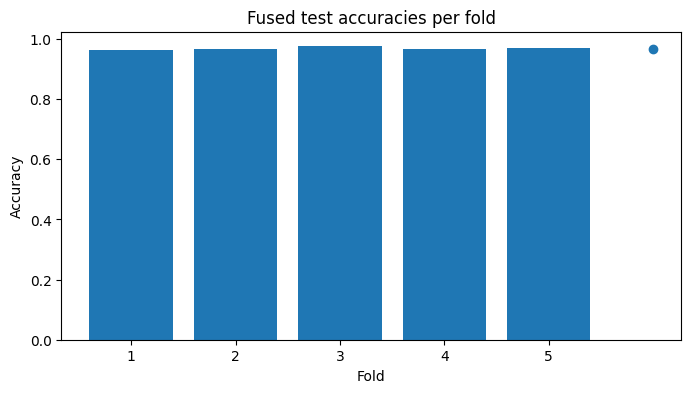

All results and plots saved to: /kaggle/working/crossVal_results


In [34]:
# Save final summary & histories
summary = {
    "fold_accuracies": fold_results.tolist(),
    "fold_macro_precision": precision_results.tolist(),
    "fold_macro_recall": recall_results.tolist(),
    "fold_macro_f1": f1_results.tolist(),
    "mean_accuracy": mean_acc,
    "std_accuracy": std_acc,
    "mean_precision": mean_pr,
    "std_precision": std_pr,
    "mean_recall": mean_rec,
    "std_recall": std_rec,
    "mean_f1": mean_f1,
    "std_f1": std_f1,
    "all_histories": all_fold_histories,
    "params": {
        "LEARNING_RATE": LEARNING_RATE,
        "BATCH_SIZE": BATCH_SIZE,
        "EPOCHS": EPOCHS,
        "MAX_LENGTH": MAX_LENGTH
    }
}

output_dir = os.path.join(OUTPUT_DIR, "cv_summary.json")
# with open(os.path.join(OUTPUT_DIR, "cv_summary.pkl"), "wb") as f:
#     pickle.dump(summary, f)
with open(output_dir, "w") as f:
    json.dump(summary, f, indent=4)

# plot the fused accuracies bar plot
plt.figure(figsize=(8,4))
plt.bar(range(1, NUM_FOLDS+1), fold_results)
plt.errorbar(NUM_FOLDS+1, mean_acc, yerr=std_acc, fmt='o', label='mean±std')
plt.title("Fused test accuracies per fold")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.xticks(range(1, NUM_FOLDS+1))
plt.savefig(os.path.join(OUTPUT_DIR, "fused_accuracy_per_fold.png"))
plt.show()
plt.close()

print(f"All results and plots saved to: {os.path.abspath(OUTPUT_DIR)}")

In [35]:
!zip -r /kaggle/working/crossVal_results.zip /kaggle/working/crossVal_results -x '*.pt'

  adding: kaggle/working/crossVal_results/ (stored 0%)
  adding: kaggle/working/crossVal_results/learning_curve_fold_2_clip.png (deflated 7%)
  adding: kaggle/working/crossVal_results/fused_accuracy_per_fold.png (deflated 20%)
  adding: kaggle/working/crossVal_results/learning_curve_fold_5_t5.png (deflated 7%)
  adding: kaggle/working/crossVal_results/learning_curve_fold_2_t5.png (deflated 5%)
  adding: kaggle/working/crossVal_results/history_fold_4.json (deflated 80%)
  adding: kaggle/working/crossVal_results/history_fold_3.json (deflated 78%)
  adding: kaggle/working/crossVal_results/history_fold_1.json (deflated 76%)
  adding: kaggle/working/crossVal_results/history_fold_5.json (deflated 79%)
  adding: kaggle/working/crossVal_results/learning_curve_fold_3_t5.png (deflated 6%)
  adding: kaggle/working/crossVal_results/cv_summary.json (deflated 83%)
  adding: kaggle/working/crossVal_results/learning_curve_fold_1_t5.png (deflated 7%)
  adding: kaggle/working/crossVal_results/learning_c

In [36]:
print("All done!!!!!")

All done!!!!!
